# Check Mayo-Kebbi

Make sure that Mayo-Kebbi flood exposure is correlated enough with N'Djamena

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [40]:
import ocha_stratus as stratus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.constants import *

In [41]:
def detrend_column(
    df: pd.DataFrame,
    col: str,
    index_col: str = "valid_date",
    min_index=None,
    max_index=None,
) -> pd.DataFrame:
    """
    Detrend a column in a DataFrame using linear regression (via NumPy).

    Parameters:
    -----------
    df : pd.DataFrame
        The input DataFrame. Must contain a datetime column.
    col : str
        The name of the column to detrend.
    time_col : str
        The name of the datetime column. Default is "valid_date".

    Returns:
    --------
    pd.DataFrame
        Copy of the input DataFrame with a new column: <col>_detrended
    """
    if min_index is None:
        min_index = df[index_col].min()
    if max_index is None:
        max_index = df[index_col].max()

    df_sorted = df.sort_values(index_col).copy()
    df_model = df_sorted[
        (df_sorted[index_col] >= min_index)
        & (df_sorted[index_col] <= max_index)
    ]

    x = df_model[index_col]
    y = df_model[col].values

    # Linear regression fit
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]

    trend = a * df_sorted[index_col] + b
    detrended = df_sorted[col] - trend
    detrended += y.mean()  # Shift to preserve original mean

    df_sorted[f"{col}_detrended"] = detrended

    return df_sorted

In [10]:
query = """
SELECT *
FROM app.floodscan_exposure
WHERE pcode = '{pcode}'
"""

In [17]:
dfs = []
for pcode in [NDJAMENA1, MAYOKEBBIEST1]:
    df_in = pd.read_sql(
        query.format(pcode=pcode),
        stratus.get_engine(stage="prod"),
        parse_dates=["valid_date"],
    )
    dfs.append(df_in)

df_exp = pd.concat(dfs, ignore_index=True)

In [18]:
df_exp.dtypes

iso3                  object
adm_level             object
valid_date    datetime64[ns]
pcode                 object
sum                  float64
dtype: object

In [20]:
df_exp_yearly = (
    df_exp.groupby(["pcode", df_exp["valid_date"].dt.year])["sum"]
    .max()
    .reset_index()
)

<Axes: xlabel='valid_date'>

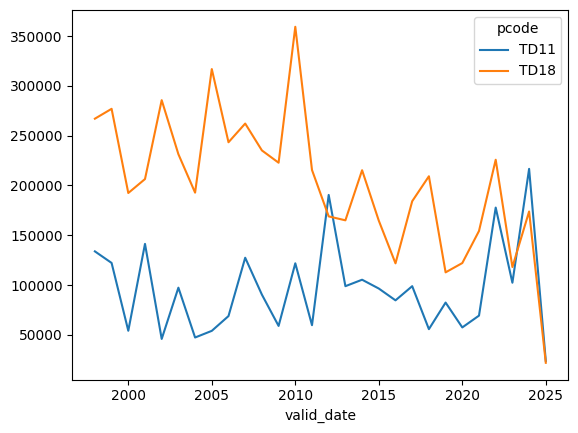

In [37]:
df_plot.plot()

In [24]:
df_plot = df_exp_yearly.pivot(
    values="sum", columns="pcode", index="valid_date"
)

In [42]:
df_plot

pcode,TD11,TD18
valid_date,,
1998,133783.0,267082.0
1999,122160.0,276989.0
2000,54018.0,192415.0
2001,141316.0,206428.0
2002,45812.0,285687.0
2003,97298.0,231404.0
2004,47249.0,192779.0
2005,53934.0,316939.0
2006,68779.0,243403.0


In [54]:
df_plot_detrend = detrend_column(df_plot.reset_index(), NDJAMENA1)
df_plot_detrend = detrend_column(df_plot_detrend, MAYOKEBBIEST1).set_index(
    "valid_date"
)

In [55]:
df_plot_detrend

pcode,TD11,TD18,TD18_detrended,TD11_detrended
valid_date,,,,
1998,133783.0,267082.0,191206.690887,140662.949507
1999,122160.0,276989.0,206734.084154,128530.323618
2000,54018.0,192415.0,127780.477422,59878.697729
2001,141316.0,206428.0,147413.870690,146667.071839
2002,45812.0,285687.0,232293.263957,50653.445950
2003,97298.0,231404.0,183630.657225,101629.820060
2004,47249.0,192779.0,150626.050493,51071.194171
2005,53934.0,316939.0,280406.443760,57246.568281
2006,68779.0,243403.0,212490.837028,71581.942392


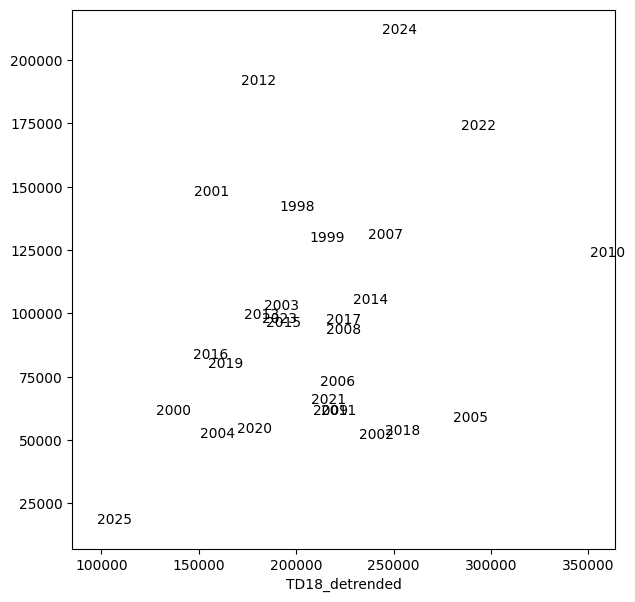

In [60]:
fig, ax = plt.subplots(figsize=(7, 7))

df_plot_detrend.plot(
    x=NDJAMENA1 + "_detrended",
    y=MAYOKEBBIEST1 + "_detrended",
    ax=ax,
    linewidth=0,
    legend=False,
)

for year, row in df_plot_detrend.iterrows():
    ax.annotate(
        year,
        (row[NDJAMENA1 + "_detrended"], row[MAYOKEBBIEST1 + "_detrended"]),
    )

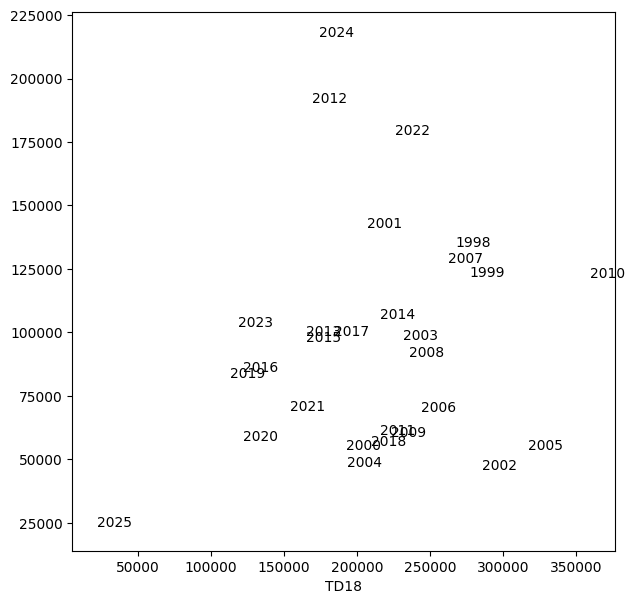

In [62]:
fig, ax = plt.subplots(figsize=(7, 7))

df_plot_detrend.plot(
    x=NDJAMENA1,
    y=MAYOKEBBIEST1,
    ax=ax,
    linewidth=0,
    legend=False,
)

for year, row in df_plot_detrend.iterrows():
    ax.annotate(
        year,
        (row[NDJAMENA1], row[MAYOKEBBIEST1]),
    )

In [63]:
df_plot_detrend.corr()

pcode,TD11,TD18,TD18_detrended,TD11_detrended
pcode,,,,
TD11,1.000000,0.160540,0.294922,0.995860
TD18,0.160540,1.000000,0.748687,0.221722
TD18_detrended,0.294922,0.748687,1.000000,0.296148
TD11_detrended,0.995860,0.221722,0.296148,1.000000


<Axes: xlabel='valid_date'>

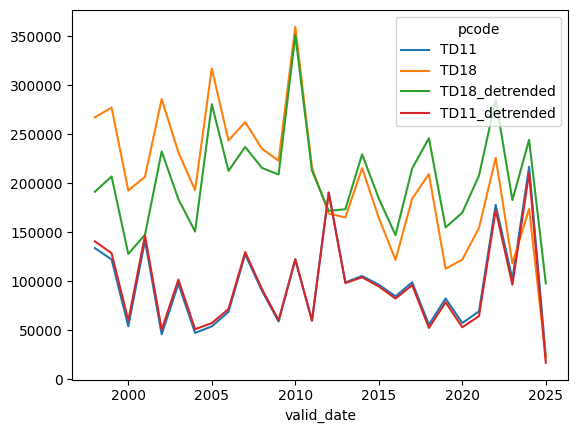

In [64]:
df_plot_detrend.plot()